### Analysis of Probability Distribution Priors from ResStock

heating_setpoint: 22.0,

cooling_setpoint: 26.6,

people_per_area: 3.0,

infil_flow_rate_living: 0.01,

infil_flow_rate_garage: 0.05,

infil_flow_rate_attic: 0.05,

watts_equip: 500, Can't find this

watts_lights: 1000, Can't find this

heating_COP: 4.0,

fan_efficiency: 0.7,

pressure_rise: 400.0,

solar_transmittance: 0.837,

burner_eff: 0.8,

vent_flow_rate: 0.131944

Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.stats import gaussian_kde, gamma, norm, truncnorm
from scipy.interpolate import interp1d
from pathlib import Path
import time
from eppy.modeleditor import IDF
import shutil
import os
from mpi4py import MPI
import SALib
from SALib.sample import sobol


Configurations

In [2]:
resstock_dir = "/jumbo/keller-lab/Jeremy_Wang/resstock"
housing_characteristics_dir = os.path.join(resstock_dir, "project_national", "housing_characteristics")
# options_dir = os.path.join(resstock_dir, "resources", "options_lookup.tsv")

Reading Options File

In [3]:
# # Read all lines manually, pad short rows with NaN
# with open(options_dir, 'r') as f:
#     lines = [line.strip().split('\t') for line in f]

# header = lines[0]
# max_cols = max(len(row) for row in lines[1:])

# # Pad header if it's shorter than some rows
# while len(header) < max_cols:
#     header.append(f'col_{len(header)}')

# # Pad each row with None (becomes NaN in DataFrame)
# padded = [row + [None] * (max_cols - len(row)) for row in lines[1:]]

# options = pd.DataFrame(padded, columns=header)

List of all TSV Files Available

In [4]:
# tsv_files = [f for f in os.listdir(housing_characteristics_dir) if f.endswith('.tsv')]

Function for extracting and cleaning TSV Files

In [5]:
def extract_and_clean (filename):
    df = pd.read_csv(os.path.join(housing_characteristics_dir, filename), sep='\t')

    # removing missing columns
    dep_cols = [c for c in df.columns if c.startswith("Dependency=")]
    filtered = df[
        (~df[dep_cols].eq("Not Available").any(axis=1)) &
        (df[dep_cols].notna().all(axis=1))
    ]
    return filtered


#### Heating setpoint 

In [6]:
def extract_heating_probs():
    # reading heating_setpoint file
    heating_setpoint = extract_and_clean("Heating Setpoint.tsv")

    # skeleton IDF constraints
    climate_zone = "5A" # chicago 
    building_type = "Single-Family Detached" 
    HVAC_heating_type = "Ducted Heat Pump"

    # filter by constraints
    mask = (
        (heating_setpoint['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
        (heating_setpoint['Dependency=Geometry Building Type RECS'] == building_type) &
        (heating_setpoint['Dependency=HVAC Heating Type'] == HVAC_heating_type) # &
        # (heating_setpoint['Dependency=HVAC Has Zonal Electric Heating'] == 'No')
        )

    heating_filtered = heating_setpoint[mask]

    # delete misinputted dataset
    heating_filtered = heating_filtered[heating_filtered['Dependency=Tenure'] != 'Not Available']

    # Get option columns
    opt_cols = [c for c in heating_filtered.columns if c.startswith('Option=')]

    # Weight by source_weight
    heating_weights = heating_filtered['source_weight'].values
    heating_weights = heating_weights / heating_weights.sum()

    # Weighted average across tenure types
    heating_weighted_probs = pd.Series(
        np.average(heating_filtered[opt_cols].values, axis=0, weights=heating_weights),
        index=opt_cols
    )

    ### convert setpoints from fahrenheit to celsius
    # Convert option names from F to C
    def f_to_c(f):
        return (f - 32) * 5/9

    # Extract numeric F values from option names
    heating_f_values = np.array([float(c.replace('Option=', '').replace('F', '')) 
                        for c in opt_cols])

    # Convert to Celsius
    heating_c_values = f_to_c(heating_f_values)

    heating_prior = pd.DataFrame()
    heating_prior["Temp"] = heating_c_values
    heating_prior["Prob"] = heating_weighted_probs.values

    return heating_prior

### Using Continuous Distributions to Fit Data

In [7]:
# fit data from weighted probabilites to a gamma distribution
def fit_data(prior, seed):
    # load data
    x = prior.iloc[:, 0].values
    w = prior.iloc[:, 1].values
    # normalize weights
    w = w / w.sum()

    # create seeded RNG
    rng = np.random.default_rng(seed)

    # Gamma distribution fit
    samples = rng.choice(x, size=10000, p=w)
    ### Gamma distribution fit
    # samples = np.random.choice(x, size=10000, p=w)
    shape, loc_g, scale_g = gamma.fit(samples, floc=0)

    return shape, loc_g, scale_g


In [9]:
# fits data and for KDE, gamma, and returns fit
def plot_fitdata(prior):
    # load data
    x = prior.iloc[:, 0].values
    w = prior.iloc[:, 1].values
    # normalize weights
    w = w / w.sum()

    ### KDE
    kde = gaussian_kde(x, weights=w)

    # scale KDE to match probability bars
    dx = np.mean(np.diff(np.sort(x)))

    xs_KDE = np.linspace(x.min() - 2*dx, x.max() + 2*dx, 500)
    ys_KDE = kde(xs_KDE)
    ys_KDE_scaled = ys_KDE * dx

    ### Gamma distribution fit
    samples = np.random.choice(x, size=10000, p=w)
    shape, loc_g, scale_g = gamma.fit(samples, floc=0)

    xs_gamma = np.linspace(x.min() - 2*dx, x.max() + 2*dx, 500)
    ys_gamma = gamma.pdf(xs_gamma, shape, loc=loc_g, scale=scale_g)
    ys_gamma_scaled = ys_gamma * dx

    ### Plotting

    plt.figure(figsize=(8, 5))

    # discrete probabilities
    plt.bar(
        x,
        w,
        width=dx/3,
        alpha=0.4,
        label="Discrete probabilities"
    )

    # KDE
    # plt.plot(xs_KDE, ys_KDE_scaled, linewidth=2, label="Weighted KDE")

    # Gamma fit
    plt.plot(xs_gamma, ys_gamma_scaled, linewidth=2, label="Gamma fit")

    plt.xlabel(prior.columns[0])
    plt.ylabel("Density / Probability")
    plt.title("Distribution Fit Comparison")
    plt.legend()
    plt.show()

    return shape, loc_g, scale_g



In [10]:
# extract key params used for inverse CDF transformation onto the gamma fit
seed = 1
fit_data(extract_heating_probs(), seed=seed)

(194.1549540765903, 0, 0.10721133133126115)

### Cooling Setpoint

In [8]:
def extract_cooling_probs():
    # reading cooling_setpoint file
    cooling_setpoint = extract_and_clean("Cooling Setpoint.tsv")

    # skeleton IDF constraints
    climate_zone = "5A" # chicago 
    building_type = "Single-Family Detached" 
    HVAC_cooling_type = "Ducted Heat Pump"

    # filter by constraints
    mask = (
        (cooling_setpoint['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
        (cooling_setpoint['Dependency=Geometry Building Type RECS'] == building_type) &
        (cooling_setpoint['Dependency=HVAC Cooling Type'] == HVAC_cooling_type)
        )
    cooling_filtered = cooling_setpoint[mask]
    cooling_filtered = cooling_filtered[cooling_filtered['Dependency=Tenure'] != 'Not Available']
    cooling_filtered = cooling_filtered.drop(columns=['Option=Void'], errors='ignore')

    # Get option columns
    opt_cols = [c for c in cooling_filtered.columns if c.startswith('Option=')]

    # Weight by source_weight
    cooling_weights = cooling_filtered['source_weight'].values
    cooling_weights = cooling_weights / cooling_weights.sum()
    # Weighted average across tenure types
    cooling_weighted_probs = pd.Series(
        np.average(cooling_filtered[opt_cols].values, axis=0, weights=cooling_weights),
        index=opt_cols
    )

    ### convert setpoints from fahrenheit to celsius
    # Convert option names from F to C
    def f_to_c(f):
        return (f - 32) * 5/9

    # Extract numeric F values from option names
    cooling_f_values = np.array([float(c.replace('Option=', '').replace('F', '')) 
                        for c in opt_cols])

    # Convert to Celsius
    cooling_c_values = f_to_c(cooling_f_values)

    cooling_prior = pd.DataFrame()
    cooling_prior["Temp"] = cooling_c_values
    cooling_prior["Prob"] = cooling_weighted_probs.values

    return cooling_prior

### Gap

In [9]:
sd_frac = 0.05
seed = 1

# returns mean and std params 
def extract_gap_info(seed):
    # extract key params used for inverse CDF transformation onto the gamma fit
    cooling_shape, cooling_loc_g, cooling_scale_g = fit_data(extract_cooling_probs(), seed=seed)
    heating_shape, heating_loc_g, heating_scale_g = fit_data(extract_heating_probs(), seed=seed)

    # extracting "mean" and "std" from the gamma distribution
    heating_mean = heating_shape * heating_scale_g + heating_loc_g
    cooling_mean = cooling_shape * cooling_scale_g + cooling_loc_g

    # multiply by the standard fraction 
    gap_mean = cooling_mean - heating_mean
    gap_std = gap_mean * sd_frac

    return gap_mean, gap_std

#### People

In [10]:
def extract_people_prior():
    # reading file
    people_filtered = extract_and_clean("Occupants.tsv")

    # IDF constraints
    building_type = "Single-Family Detached" 
    census_division = "East North Central"
    bedrooms = "3" # assume 3 bedrooms because IDF specifies that number of occupants

    # Note: Not controlling for income, metro status, or tenure status

    # mask
    mask = (
        (people_filtered['Dependency=Geometry Building Type RECS'] == building_type) &
        (people_filtered['Dependency=Census Division'] == census_division) & 
        (people_filtered['Dependency=Bedrooms'] == bedrooms)
    )

    people_filtered = people_filtered[mask]

    # Get option columns
    opt_cols = [c for c in people_filtered.columns if c.startswith('Option=')]

    # Weight by source_weight
    people_weights = people_filtered['source_weight'].values
    people_weights = people_weights / people_weights.sum()

    # Weighted average across dependency types
    people_weighted_probs = pd.Series(
        np.average(people_filtered[opt_cols].values, axis=0, weights=people_weights),
        index=opt_cols
    )

    people_values = np.array([
        float(c.replace("Option=", "").replace("+", ""))  # remove 'Option=' and '+'
        for c in opt_cols
    ])

    people_prior = pd.DataFrame()
    people_prior["People"] = people_values
    people_prior["Prob"] = people_weighted_probs.values

    return people_prior

#### Infiltration Rate

Assumptions:
Living Zone, Garage Zone, Attic Zone all use the same infiltration rate

CC (Conversion Coefficient) between ACH50 to ACH = 22.2

Floor Area = 186 m^2

Height = 3 m

In [11]:
def extract_infil_prior():
    infil_filtered = extract_and_clean("Infiltration.tsv")

    # IDF Constraints
    climate_zone = "5A" # Chicago  
    floor_area = ["1500-1999","2000-2499"] # consider floor areas ranging from 1500 - 2499 ft^2

    mask = (
        (infil_filtered['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
        ((infil_filtered['Dependency=Geometry Floor Area'] == floor_area[0]) | (infil_filtered['Dependency=Geometry Floor Area'] == floor_area[1]))
    )

    infil_filtered = infil_filtered[mask]

    opt_cols = [c for c in infil_filtered.columns if c.startswith("Option=")]

    # weight by sampling probability
    infil_probs = pd.Series(
        np.average(
            infil_filtered[opt_cols].values,
            axis=0,
            weights=infil_filtered["sampling_probability"]
        ),
        index=opt_cols
    )

    # unit conversations 
    CC = 22.2 # conversion coefficient
    FA = 186 # Floor Area m^2
    H = 3 # Height  m 

    ACH50_values = np.array([float(c.replace('Option=', '').replace('ACH50', '')) 
                        for c in opt_cols])

    Q_values = (ACH50_values * (FA * H))/(3600*CC) # converting into m^3/s

    infil_prior = pd.DataFrame()
    infil_prior["Q"] = Q_values
    infil_prior["Prob"] = infil_probs.values
    
    return infil_prior


#### Equipment Watts

Can't find baseline value, and distribution is a singular point

In [ ]:
# use TSV file titled "plug loads"
equip_filtered = extract_and_clean("Plug Loads.tsv")
# IDF constraints
census_division = "East North Central"
building_type = "Single-Family Detached"

mask = (
    (equip_filtered['Dependency=Census Division RECS'] == census_division) &
    (equip_filtered['Dependency=Geometry Building Type RECS'] == building_type)
)

equip_filtered = equip_filtered[mask]

#### Lighting Watts

Options are quantitatively describing the type of lights being used

Need Lookup table

In [12]:
def extract_lighting_probs():
    lighting = extract_and_clean("Lighting.tsv")

    # constraints
    state = "IL"
    building_type = "Single-Family Detached"

    mask = (
        (lighting['Dependency=State'] == state) & 
        (lighting['Dependency=Geometry Building Type RECS'] == building_type)
    )

    lighting = lighting[mask]

    # Get option columns
    opt_cols = [c for c in lighting.columns if c.startswith('Option=')]

    # Weight by source_weight
    lighting_weights = lighting['source_weight'].values
    lighting_weights = lighting_weights / lighting_weights.sum()

    # Weighted average across dependency types
    lighting_weighted_probs = pd.Series(
        np.average(lighting[opt_cols].values, axis=0, weights=lighting_weights),
        index=opt_cols
    )
    # calculating kwh/yr for interior lighting (assume this encapsulates all lighting energy use)
    # Use the same equation for interior as attic and garage

    # constants
    ffa = 2000 # floor area in ft^2
    l_hw = 0.8*(ffa*0.542+334) # interior plug in lighting, kwh/yr
    er_cfl = 0.27 # efficiency rating of CFL
    er_led = 0.3 # efficiency rating of LED
    er_lf = 0.17 # efficiency rating of linear fluorescent
    f_lf = 0 # fraction of linear fluorescent lighting, which we will assume is 0 for simplicity

    # calculate kwh/yr for each lighting type
    def calculate_lighting_kwh(f_inc, f_cfl, f_led):
        SAF = 1.1*f_inc**4 - 1.9*f_inc**3 + 1.5*f_inc**2 - 0.7*f_inc + 1 # smart replacement algorithm factor

        lighting_kwh_yr = l_hw * (((f_inc+0.34)+(f_cfl-0.21)*er_cfl + f_led*er_led + (f_lf-0.13)*er_lf)*SAF*0.9 + 0.1)
        # hours of usage per day
        hours_per_day = 2.7 
        lighting_watts = lighting_kwh_yr * 1000 / (365*hours_per_day) # convert to watts

        return lighting_watts

    lighting_inc = calculate_lighting_kwh(f_inc = 1, f_cfl = 0, f_led = 0)
    lighting_cfl = calculate_lighting_kwh(f_inc = 0, f_cfl = 1, f_led = 0)
    lighting_led = calculate_lighting_kwh(f_inc = 0, f_cfl = 0, f_led = 1)

    lighting_lookup = {
        "Option=100% Incandescent": lighting_inc,
        "Option=100% CFL": lighting_cfl,
        "Option=100% LED": lighting_led
    }

    lighting_weighted_probs = lighting_weighted_probs.reset_index()
    lighting_weighted_probs.columns = ["lighting_option", "probability"]

    lighting_weighted_probs["watts"] = (
        lighting_weighted_probs["lighting_option"]
        .map(lighting_lookup)
    )

    return lighting_weighted_probs 

In [ ]:
lighting = extract_and_clean("Lighting.tsv")

# constraints
state = "IL"
building_type = "Single-Family Detached"

mask = (
    (lighting['Dependency=State'] == state) & 
    (lighting['Dependency=Geometry Building Type RECS'] == building_type)
)

lighting = lighting[mask]

# Get option columns
opt_cols = [c for c in lighting.columns if c.startswith('Option=')]

# Weight by source_weight
lighting_weights = lighting['source_weight'].values
lighting_weights = lighting_weights / lighting_weights.sum()

# Weighted average across dependency types
lighting_weighted_probs = pd.Series(
    np.average(lighting[opt_cols].values, axis=0, weights=lighting_weights),
    index=opt_cols
)


In [ ]:
# calculating kwh/yr for interior lighting (assume this encapsulates all lighting energy use)
# Use the same equation for interior as attic and garage

# constants
ffa = 2000 # floor area in ft^2
l_hw = 0.8*(ffa*0.542+334) # interior plug in lighting, kwh/yr
er_cfl = 0.27 # efficiency rating of CFL
er_led = 0.3 # efficiency rating of LED
er_lf = 0.17 # efficiency rating of linear fluorescent
f_lf = 0 # fraction of linear fluorescent lighting, which we will assume is 0 for simplicity

# calculate kwh/yr for each lighting type
def calculate_lighting_kwh(f_inc, f_cfl, f_led):
    SAF = 1.1*f_inc**4 - 1.9*f_inc**3 + 1.5*f_inc**2 - 0.7*f_inc + 1 # smart replacement algorithm factor

    lighting_kwh_yr = l_hw * (((f_inc+0.34)+(f_cfl-0.21)*er_cfl + f_led*er_led + (f_lf-0.13)*er_lf)*SAF*0.9 + 0.1)
    # hours of usage per day
    hours_per_day = 2.7 
    lighting_watts = lighting_kwh_yr * 1000 / (365*hours_per_day) # convert to watts

    return lighting_watts

lighting_inc = calculate_lighting_kwh(f_inc = 1, f_cfl = 0, f_led = 0)
lighting_cfl = calculate_lighting_kwh(f_inc = 0, f_cfl = 1, f_led = 0)
lighting_led = calculate_lighting_kwh(f_inc = 0, f_cfl = 0, f_led = 1)

lighting_lookup = {
    "Option=100% Incandescent": lighting_inc,
    "Option=100% CFL": lighting_cfl,
    "Option=100% LED": lighting_led
}

In [ ]:


lighting_weighted_probs = lighting_weighted_probs.reset_index()
lighting_weighted_probs.columns = ["lighting_option", "probability"]

lighting_weighted_probs["watts"] = (
    lighting_weighted_probs["lighting_option"]
    .map(lighting_lookup)
)

In [13]:
# creating mixed normal distributions for each lighting option, then summing them together according to their probabilities to get a final distribution, which we can then sample from using the inverse CDF method
def fit_mixed_normal(probs):

    weights = probs["probability"].values
    means = probs["watts"].values

    weights = weights / weights.sum()

    stds = sd_frac * means
    x_grid = np.linspace(0, 2500, 10000)

    cdf = np.zeros_like(x_grid)
    lighting_pdf = np.zeros_like(x_grid)

    for w, mu, sd in zip(weights, means, stds):
        cdf += w * norm.cdf(x_grid, loc=mu, scale=sd)
        lighting_pdf += w * norm.pdf(x_grid, mu, sd)
    inv_cdf_lighting = interp1d(
        cdf,
        x_grid,
        bounds_error=False,
        fill_value=(x_grid[0], x_grid[-1])
    )

    return inv_cdf_lighting





In [ ]:
# inverse CDF sampling for lighting distribution
inv_cdf_lighting = fit_mixed_normal(extract_lighting_probs())

# u = np.random.rand(10000)
# lighting_samples = inv_cdf_lighting(u)


NameError: name 'x_grid' is not defined

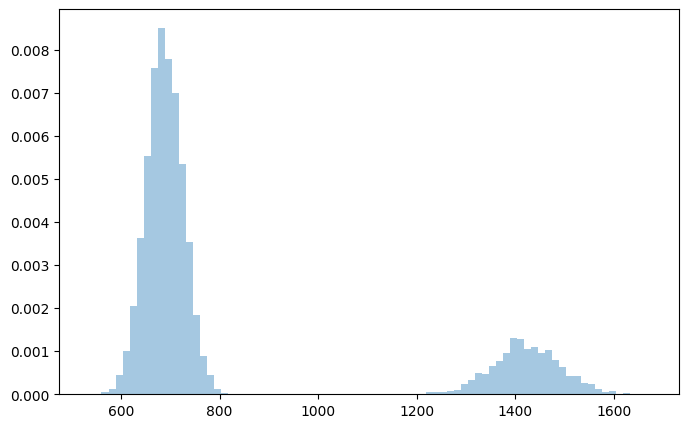

In [36]:
# Plotting to confirm
plt.figure(figsize=(8,5))

# histogram of generated samples
plt.hist(
    lighting_samples,
    bins=80,
    density=True,
    alpha=0.4,
    label='Inverse CDF samples'
)

# theoretical mixture pdf
plt.plot(
    x_grid,
    lighting_pdf,
    lw=2,
    label='Mixture PDF'
)

# original discrete points
# plt.scatter(
#     means,
#     weights,
#     s=100,
#     color='red',
#     zorder=5,
#     label='Original categories'
# )

plt.xlabel("Lighting Watts")
plt.ylabel("Density")
plt.legend()
plt.show()

#### Heating COP

No values can be found with the given dependencies

In [ ]:
heating_COP_filtered = extract_and_clean("HVAC Heating Efficiency.tsv")

# IDF Constraints
State = "Others"
heating_fuel = "Electricity"
HVAC_heating_type = "Ducted Heat Pump"


mask = (
    (heating_COP_filtered['Dependency=Custom State'] == State) &
    (heating_COP_filtered['Dependency=Heating Fuel'] == heating_fuel) & 
    (heating_COP_filtered['Dependency=HVAC Heating Type'] == HVAC_heating_type) # & 
    # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
)

heating_COP_filtered = heating_COP_filtered[mask]


#### Fan Efficiency

Unable to be sourced

#### Pressure Rise

Not found

#### Solar Transmittance

Options are quantitatively describing the type of window used

Need lookup table

In [14]:
def extract_solar_probs():
    solar_transmittance = extract_and_clean("Windows.tsv")

    # constraints
    climate_zone = "5A"
    building_type = "Single-Family Detached"

    mask = (
        (solar_transmittance['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
        (solar_transmittance['Dependency=Geometry Building Type RECS'] == building_type)  # & 
        # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
    )

    solar_transmittance = solar_transmittance[mask]
    solar_transmittance = solar_transmittance.drop(columns=['Option=Void'], errors='ignore')

    # Get option columns
    opt_cols = [c for c in solar_transmittance.columns if c.startswith('Option=')]

    # Weight by source_weight
    solar_weights = solar_transmittance['source_weight'].values
    solar_weights = solar_weights / solar_weights.sum()

    # Weighted average across dependency types
    solar_weighted_probs = pd.Series(
        np.average(solar_transmittance[opt_cols].values, axis=0, weights=solar_weights),
        index=opt_cols
    )

    # inputting lookup table
    windows_df = pd.DataFrame({
        "window_option": solar_weighted_probs.index,

        "SHGC": [
            0.67,
            0.60,
            0.56,
            0.50,
            0.52,
            0.75,
            0.68,
            0.64,
            0.58,
            0.31
        ],

        "window_type": [
            "double",
            "double",
            "double",
            "double",
            "double",
            "single",
            "single",
            "single",
            "single",
            "triple"  
        ]
    })

    # Conversions from SHGC to solar transmittance
    def shgc_to_solar_transmittance(shgc, window_type):
        # Single-pane / high-U equation
        if window_type == "single":

            if shgc < 0.7206:
                ts = (
                    0.939998 * shgc**2
                    + 0.20332 * shgc
                )
            else:
                ts = (
                    1.30415 * shgc
                    - 0.30515
                )

        # Double-pane or better equation
        else:
            if shgc <= 0.15:
                ts = 0.41040 * shgc
            else:
                ts = (
                    0.085775 * shgc**2
                    + 0.963954 * shgc
                    - 0.084958
                )
        return ts

    windows_df["solar_transmittance"] = windows_df.apply(
        lambda row: shgc_to_solar_transmittance(
            row["SHGC"],
            row["window_type"]
        ),
        axis=1
    )

    # Add solar transmittance lookup table
    solar_lookup = dict(
        zip(
            windows_df["window_option"],
            windows_df["solar_transmittance"]
        )
    )

    # Convert weighted probabilities Series into DataFrame
    solar_weighted_probs = solar_weighted_probs.reset_index()
    solar_weighted_probs.columns = [
        "window_option",
        "probability"
    ]

    # Add solar transmittance column
    solar_weighted_probs["solar_transmittance"] = (
        solar_weighted_probs["window_option"]
        .map(solar_lookup)
    )

    return solar_weighted_probs

#### Burner Efficiency

No values can be found with the given dependencies

In [ ]:
burner_filtered = extract_and_clean("HVAC Heating Efficiency.tsv")

# IDF Constraints
State = "Others"
heating_fuel = "Natural Gas"
HVAC_heating_type = "Ducted Heat Pump"


mask = (
    (burner_filtered['Dependency=Custom State'] == State) &
    (burner_filtered['Dependency=Heating Fuel'] == heating_fuel) & 
    (burner_filtered['Dependency=HVAC Heating Type'] == HVAC_heating_type) # & 
    # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
)

burner_filtered = burner_filtered[mask]

# Issue arises with no distribution available


### Inverse CDF Transformation Functions

In [15]:
# inverse CDF transformation for Gamma function
# probs is the weighted probability dataframe, seed is the seed for gamma fit
def gamma_inverse_cdf(uniform_sample, seed, probs):
    shape, loc, scale = fit_data(probs, seed=seed)
    transformed_samples = gamma.ppf(uniform_sample, a=shape, loc=loc, scale=scale)
    return transformed_samples

# inverse CDF for normal distribution
# means and parameter_std dictionary, param is parameter name
def normal_inverse_cdf(uniform_sample, means, parameter_std, param):
    mean = means[param]
    std = parameter_std[param]
    transformed_samples = norm.ppf(uniform_sample, loc=mean, scale=std)
    return transformed_samples

# inverse CDF Transformations for truncated normal (only used for gap)
def truncated_normal_inverse_cdf(uniform_sample, mean, std, param, lower_bound, upper_bound):
    # convert physical bounds to standard-normal bounds
    a = (lower_bound - mean) / std
    b = (upper_bound - mean) / std

    transformed_samples = truncnorm.ppf(
        uniform_sample,
        a,
        b,
        loc=mean,
        scale=std
    )
    return transformed_samples

# inverse CDF transformation for mixed normal (only used for lighting)
def mixed_normal_inverse_cdf(uniform_sample, probs):
    inv_cdf_lighting = fit_mixed_normal(probs)
    transformed_samples = inv_cdf_lighting(uniform_sample)
    return transformed_samples


#### Ventilation Flow Rate

Can't find parameter values

### plots

Weighted mean: 20.80C
Weighted std:  1.52C


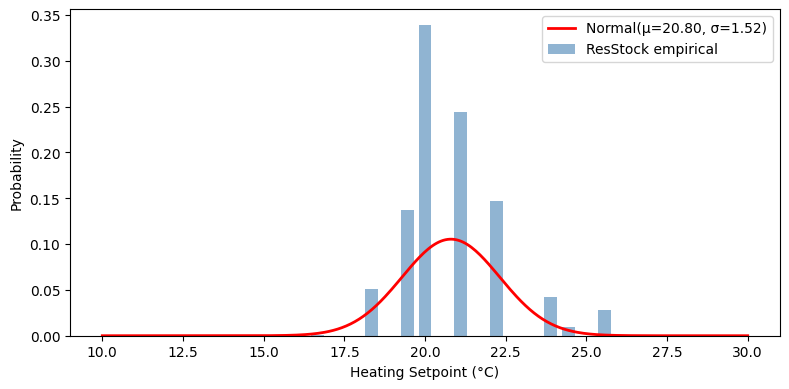


Concrete prior: Normal(mean=20.80, std=1.52)
Weighted mean: 22.18C
Weighted std:  1.97C


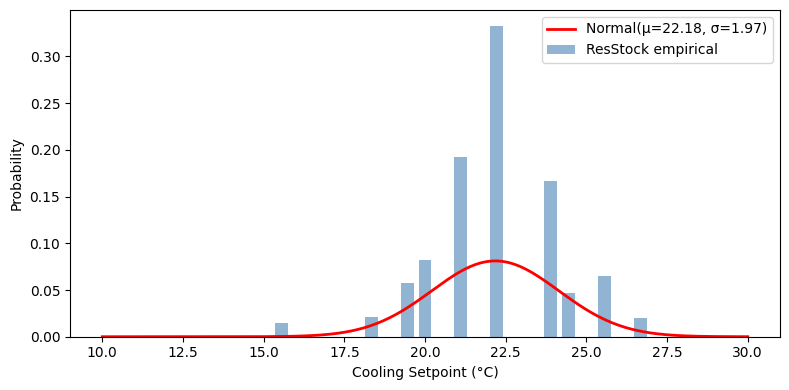


Concrete prior: Normal(mean=22.18, std=1.97)


In [ ]:

# Compute weighted mean and std directly from the distribution
def plot_setpoint_prior (c_values, weighted_probs, title):
        mean_c = np.average(c_values, weights=weighted_probs.values)
        std_c = np.sqrt(np.average((c_values - mean_c)**2, weights=weighted_probs.values))

        print(f"Weighted mean: {mean_c:.2f}C")
        print(f"Weighted std:  {std_c:.2f}C")

        x = np.linspace(10, 30, 300)
        normal_pdf = stats.norm.pdf(x, loc=mean_c, scale=std_c)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(c_values, weighted_probs.values, width=0.4, alpha=0.6,
        label='ResStock empirical', color='steelblue')
        ax.plot(x, normal_pdf * 0.4, 'r-', lw=2,
                label=f'Normal(μ={mean_c:.2f}, σ={std_c:.2f})')
        ax.set_xlabel(f'{title} (°C)')
        ax.set_ylabel('Probability')
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f"\nConcrete prior: Normal(mean={mean_c:.2f}, std={std_c:.2f})")

plot_setpoint_prior(heating_c_values, heating_weighted_probs, "Heating Setpoint")
plot_setpoint_prior(cooling_c_values, cooling_weighted_probs, "Cooling Setpoint")

## Generate Samples Using Sobol Sequence

Notes on ResStock Priors:

Heating setpoint: Gamma distribution fit

Gap: Truncated normal Distribution with mean informed by data, std uses sd fraction

People: Gamma Distribution fit

Infiltration rate: Gamma Distribution fit (use same data for attic, garage, living)

Equipment power: Normal guess, sd fraction

Lighting: mixed normal based on data, uses sd fraction

Heating COP: Normal guess, sd fraction

Fan efficiency: Normal guess, sd fraction

Pressure rise: Normal guess, sd fraction

Solar Transmittance: Gamma Distribution fit

Burner: Normal guess, sd fraction

Vent flow: Normal guess, sd fraction

In [ ]:
def generate_sobol_sequence(num_files, seed):
    #  standard deviation for each paramter is 5% of its original value
    sd_frac = 0.05

    # manually create a parameter list
    parameter_names = ['heating_setpoint', 'cooling_setpoint', 'people_per_area', 'infil_flow_rate_living', 'infil_flow_rate_garage', 'infil_flow_rate_attic', 'watts_equip', 'watts_lights', 'heating_COP', 'fan_efficiency', 'pressure_rise', 'solar_transmittance', 'burner_eff', 'vent_flow_rate', 'gap']

    ### dealing with parameters that do not have data informed distributions ### 

    # means for params without distributions 
    means = {
        'watts_equip': 500,
        'heating_COP': 4.0,
        'fan_efficiency': 0.7,
        'pressure_rise': 400.0,
        'burner_eff': 0.8,
        'vent_flow_rate': 0.131944
    }

    # param restrictions
    min_gap = 0 
    max_solar_transmittance = 1-0.075 # max solar transmittance

    # creating a dictionary to store the std
    parameter_std = {}

    # adding std into dictionary
    for name, mean in means.items():
        parameter_std[name] = mean*sd_frac

    parameter_std['burner_eff'] = sd_frac # manually change burner efficiency

    # creating problem dictionary for sobol sampling
    # requires first initially excluding the cooling setpoint because it is dependent on the heating setpoint
    names_for_problem = [n for n in parameter_names if n != 'cooling_setpoint']

    # use 0 to 1 uniform distribution for all bounds
    bounds = []
    for name in names_for_problem:
        bounds.append([0, 1])

    # creating distributions
    dists = ['unif'] * len(names_for_problem)

    # dictionary formatted for Sobol sequence
    problem = {
        'num_vars': len(names_for_problem),
        'names': names_for_problem,
        'bounds': bounds,
        'dists': dists
    }

    # conduct sobol sequence sampling
    N = 1000 # baseline number of samples
    param_values = sobol.sample(problem, N, calc_second_order=False, seed = seed) # array with dimensions [N*(P+2), P]

    ### Inverse CDF Transformations ### 

    # extracting uniform samples
    param_idx = {} # dictionary storing indexes via param names as key (used for reinserting cooling setpoint later)
    uniform_samples = {}
    for name in problem['names']:
        param_idx[name] = problem['names'].index(name)
        uniform_samples[name] = param_values[:, param_idx[name]]


    # create dictionary for transformed samples 
    transformed_samples = {}

    # Gamma distribution params
    transformed_samples['heating_setpoint'] = gamma_inverse_cdf(
        uniform_samples['heating_setpoint'],
        seed=seed,
        probs=extract_heating_probs()
    )
    transformed_samples['people_per_area'] = gamma_inverse_cdf(
        uniform_samples['people_per_area'],
        seed=seed,
        probs=extract_people_prior()
    )

    for infil_param in ['infil_flow_rate_garage', 'infil_flow_rate_attic', 'infil_flow_rate_living']:
        transformed_samples[infil_param] = gamma_inverse_cdf(
            uniform_samples[infil_param],
            seed=seed,
            probs=extract_infil_prior()
        )

    transformed_samples['solar_transmittance'] = gamma_inverse_cdf(
        uniform_samples['solar_transmittance'],
        seed=seed,
        probs = extract_solar_probs()[["solar_transmittance", "probability"]]
    )
    # enforce max solar transmittance (set all values above max to the max)
    transformed_samples['solar_transmittance'] = transformed_samples[
        'solar_transmittance'
    ].clip(max=max_solar_transmittance)

    # Normal Distribution params 
    for param in ['watts_equip','heating_COP', 'fan_efficiency', 'pressure_rise', 'burner_eff', 'vent_flow_rate']:
        transformed_samples[param] = normal_inverse_cdf(
            uniform_samples[param],
            means=means,
            parameter_std=parameter_std,
            param=param
        )

    # Truncated Normal Distribution
    transformed_samples['gap'] = truncated_normal_inverse_cdf(
        uniform_samples['gap'],
        extract_gap_info(seed=seed)[0], # mean
        extract_gap_info(seed=seed)[1], # std
        param='gap',
        lower_bound=min_gap,
        upper_bound=np.inf
    )

    # Mixed noraml Distribution
    transformed_samples['watts_lights'] = mixed_normal_inverse_cdf(
        uniform_samples['watts_lights'],
        probs = extract_lighting_probs()
    )

    ### adding cooling setpoint using gap data
    transformed_samples['cooling_setpoint'] = transformed_samples['heating_setpoint'] + transformed_samples['gap']

    ### creating new array with transformed samples
    transformed_param_values = np.column_stack(
        [transformed_samples[param] for param in parameter_names]
    )
    transformed_param_values = np.delete(transformed_param_values, param_idx['gap']+1, axis=1) # deleting the gap column of values
    parameter_names.remove('gap') # delete gap from list of parameters

    ### Creating samples
    # convert param_values into a list of dictionaries, where the keys correspond to the input parameters
    samples = []
    for i in range(len(transformed_param_values)):
        sample_dict = {}
        for j in range(param_values.shape[1]):
            sample_dict[parameter_names[j]] = transformed_param_values[i,j]
        samples.append(sample_dict)

    ### validating samples 
    invalid_samples = []
    for i, sdict in enumerate(samples):
        # making sure heating point is below cooling point
        if  (sdict['cooling_setpoint'] - sdict['heating_setpoint']) < min_gap:
            print('Setpoint Error')
            invalid_samples.append(i)

    if not invalid_samples:
        print("No invalid samples")
    else:
        print("Invalid samples:", invalid_samples)

    ### returning outputs
    return samples

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.stats import gaussian_kde, gamma, norm

# temporarily set seed to 1
seed = 1

#  standard deviation for each paramter is 5% of its original value
sd_frac = 0.05

# manually create a parameter list
parameter_names = ['heating_setpoint', 'cooling_setpoint', 'people_per_area', 'infil_flow_rate_living', 'infil_flow_rate_garage', 'infil_flow_rate_attic', 'watts_equip', 'watts_lights', 'heating_COP', 'fan_efficiency', 'pressure_rise', 'solar_transmittance', 'burner_eff', 'vent_flow_rate', 'gap']

### dealing with parameters that do not have data informed distributions ### 

# means for params without distributions 
means = {
    'watts_equip': 500,
    'heating_COP': 4.0,
    'fan_efficiency': 0.7,
    'pressure_rise': 400.0,
    'burner_eff': 0.8,
    'vent_flow_rate': 0.131944
}

# param restrictions
min_gap = 0 
max_solar_transmittance = 1-0.075 # max solar transmittance

# creating a dictionary to store the std
parameter_std = {}

# adding std into dictionary
for name, mean in means.items():
    parameter_std[name] = mean*sd_frac

parameter_std['burner_eff'] = sd_frac # manually change burner efficiency

# creating problem dictionary for sobol sampling
# requires first initially excluding the cooling setpoint because it is dependent on the heating setpoint
names_for_problem = [n for n in parameter_names if n != 'cooling_setpoint']

# use 0 to 1 uniform distribution for all bounds
bounds = []
for name in names_for_problem:
    bounds.append([0, 1])

# creating distributions
dists = ['unif'] * len(names_for_problem)

# dictionary formatted for Sobol sequence
problem = {
    'num_vars': len(names_for_problem),
    'names': names_for_problem,
    'bounds': bounds,
    'dists': dists
}

# conduct sobol sequence sampling
N = 1000 # baseline number of samples
param_values = sobol.sample(problem, N, calc_second_order=False, seed = seed) # array with dimensions [N*(P+2), P]

### Inverse CDF Transformations ### 

# extracting uniform samples
param_idx = {} # dictionary storing indexes via param names as key (used for reinserting cooling setpoint later)
uniform_samples = {}
for name in problem['names']:
    param_idx[name] = problem['names'].index(name)
    uniform_samples[name] = param_values[:, param_idx[name]]


# create dictionary for transformed samples 
transformed_samples = {}

# Gamma distribution params
transformed_samples['heating_setpoint'] = gamma_inverse_cdf(
    uniform_samples['heating_setpoint'],
    seed=seed,
    probs=extract_heating_probs()
)
transformed_samples['people_per_area'] = gamma_inverse_cdf(
    uniform_samples['people_per_area'],
    seed=seed,
    probs=extract_people_prior()
)

for infil_param in ['infil_flow_rate_garage', 'infil_flow_rate_attic', 'infil_flow_rate_living']:
    transformed_samples[infil_param] = gamma_inverse_cdf(
        uniform_samples[infil_param],
        seed=seed,
        probs=extract_infil_prior()
    )

transformed_samples['solar_transmittance'] = gamma_inverse_cdf(
    uniform_samples['solar_transmittance'],
    seed=seed,
    probs = extract_solar_probs()[["solar_transmittance", "probability"]]
)
# enforce max solar transmittance (set all values above max to the max)
transformed_samples['solar_transmittance'] = transformed_samples[
    'solar_transmittance'
].clip(max=max_solar_transmittance)

# Normal Distribution params 
for param in ['watts_equip','heating_COP', 'fan_efficiency', 'pressure_rise', 'burner_eff', 'vent_flow_rate']:
    transformed_samples[param] = normal_inverse_cdf(
        uniform_samples[param],
        means=means,
        parameter_std=parameter_std,
        param=param
    )

# Truncated Normal Distribution
transformed_samples['gap'] = truncated_normal_inverse_cdf(
    uniform_samples['gap'],
    extract_gap_info(seed=seed)[0], # mean
    extract_gap_info(seed=seed)[1], # std
    param='gap',
    lower_bound=min_gap,
    upper_bound=np.inf
)

# Mixed noraml Distribution
transformed_samples['watts_lights'] = mixed_normal_inverse_cdf(
    uniform_samples['watts_lights'],
    probs = extract_lighting_probs()
)

### adding cooling setpoint using gap data
transformed_samples['cooling_setpoint'] = transformed_samples['heating_setpoint'] + transformed_samples['gap']

### creating new array with transformed samples
transformed_param_values = np.column_stack(
    [transformed_samples[param] for param in parameter_names]
)
transformed_param_values = np.delete(transformed_param_values, param_idx['gap']+1, axis=1) # deleting the gap column of values
parameter_names.remove('gap') # delete gap from list of parameters

### Creating samples
# convert param_values into a list of dictionaries, where the keys correspond to the input parameters
samples = []
for i in range(len(transformed_param_values)):
    sample_dict = {}
    for j in range(param_values.shape[1]):
        sample_dict[parameter_names[j]] = transformed_param_values[i,j]
    samples.append(sample_dict)

### validating samples 
invalid_samples = []
for i, sdict in enumerate(samples):
    # making sure heating point is below cooling point
    if  (sdict['cooling_setpoint'] - sdict['heating_setpoint']) < min_gap:
        print('Setpoint Error')
        invalid_samples.append(i)

if not invalid_samples:
    print("No invalid samples")
else:
    print("Invalid samples:", invalid_samples)



/jumbo/keller-lab/Applications/mambaforge/envs/eplus/lib/python3.9/site-packages/scipy/stats/_qmc.py:804: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


No invalid samples
